<a href="https://colab.research.google.com/github/minbj1226/pytorch-basics/blob/main/03_Dataset_DataLoader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Dataset
- 샘플 1개를 읽고 반환하는 객체
- ```__len__```, ```__getitem__```이 핵심

### 2. DataLoader
- Dataset에서 샘플을 가져와 batch로 묶고 반복하게 해주는 객체

### 3. batch_size
- 한 번에 모델에 넣는 데이터 개수

### 4. __getitem__
- 특정 인덱스의 샘플 1개를 어떻게 반환할지 정의

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

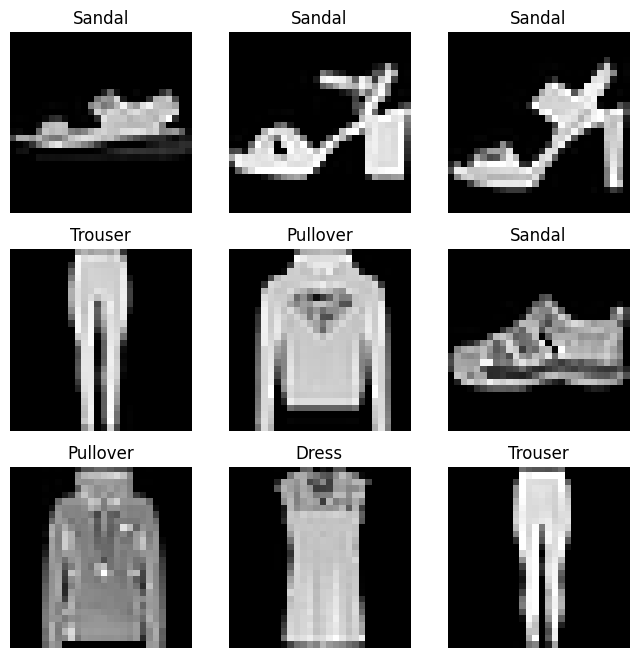

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')

plt.show()

In [ ]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
     self.img_labels = pd.read_csv(annotations_file, names=['file_name', 'label'])
     self.img_dir = img_dir
     self.transform = transform
     self.target_transform = target_transform

  def __len__(self):
     return len(self.img_labels)

  def __getitem__(self, idx):
     img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
     image = read_image(img_path)
     label = self.img_labels.iloc[idx, 1]
     if self.transform:
        image = self.transform(image)
     if self.target_transform:
        label = self.target_transform(label)
     return image, label

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


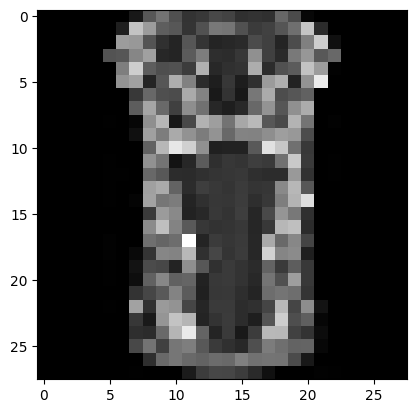

Label: 6


In [ ]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap='gray')
plt.show()
print(f"Label: {label}")

In [ ]:
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

import warnings
warnings.filterwarnings('ignore')

plt.ion()

In [ ]:
landmarks_frame = pd.read_csv('data/faces/face_landmarks.csv')

landmarks_frame

,image_name,part_0_x,part_0_y,part_1_x,part_1_y,part_2_x,part_2_y,part_3_x,part_3_y,part_4_x,...,part_63_x,part_63_y,part_64_x,part_64_y,part_65_x,part_65_y,part_66_x,part_66_y,part_67_x,part_67_y
0,0805personali01.jpg,27,83,27,98,29,113,33,127,39,...,93,136,100,141,93,135,89,135,84,134
1,1084239450_e76e00b7e7.jpg,70,236,71,257,75,278,82,299,90,...,148,311,179,308,149,312,137,314,128,312
2,10comm-decarlo.jpg,66,114,65,128,67,142,68,156,72,...,128,162,136,167,127,166,121,165,116,164
3,110276240_bec305da91.jpg,42,140,45,161,51,180,61,200,73,...,144,197,180,189,147,204,136,208,125,209
4,1198_0_861.jpg,138,392,141,427,145,464,152,501,166,...,293,507,331,511,294,516,279,518,265,516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,matt-mathes.jpg,85,152,83,173,83,195,85,217,91,...,160,224,190,225,162,236,151,237,141,235
65,person-7.jpg,32,65,33,76,34,86,34,97,37,...,79,98,91,99,79,99,74,99,69,99
66,person.jpg,78,83,79,93,80,103,81,112,85,...,119,115,132,114,120,121,114,122,109,121
67,person_TjahjonoDGondhowiardjo.jpg,41,92,41,103,43,114,44,125,48,...,85,130,94,130,85,128,81,128,77,128


In [ ]:
landmarks_frame = pd.read_csv('data/faces/face_landmarks.csv')

n = 65
img_name = landmarks_frame.iloc[n, 0]
landmarks = landmarks_frame.iloc[n, 1:]
landmarks = np.asarray(landmarks, dtype='float').reshape(-1, 2)

print('Image name: {}'.format(img_name))
print('Landmarks shape: {}'.format(landmarks.shape))
print('First 4 Landmarks: {}'.format(landmarks[:4]))

Image name: person-7.jpg
Landmarks shape: (68, 2)
First 4 Landmarks: [[32. 65.]
 [33. 76.]
 [34. 86.]
 [34. 97.]]


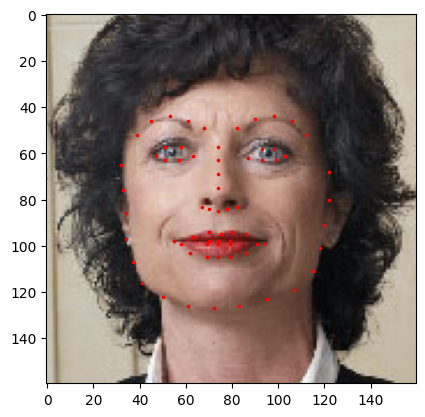

In [ ]:
def show_landmarks(image, landmarks):
  plt.imshow(image)
  plt.scatter(landmarks[:, 0], landmarks[:, 1], s=10, marker='.', c='r')
  plt.pause(0.001)

plt.figure()
show_landmarks(io.imread(os.path.join('data/faces/', img_name)), landmarks)
plt.show()

In [ ]:
class FaceLandmarksDataset(Dataset):
  def __init__(self, csv_file, root_dir, transform=None):
    self.landmarks_frame = pd.read_csv(csv_file)
    self.root_dir = root_dir
    self.transform = transform

  def __len__(self):
    return len(self.landmarks_frame)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()

    img_name = os.path.join(self.root_dir,
                            self.landmarks_frame.iloc[idx, 0])
    image = io.imread(img_name)
    landmarks = self.landmarks_frame.iloc[idx, 1:]
    landmarks = np.array([landmarks], dtype='float').reshape(-1, 2)

    sample = {'image': image, 'landmarks': landmarks}

    if self.transform:
      sample = self.transform(sample)

    return sample

0 (324, 215, 3) (68, 2)


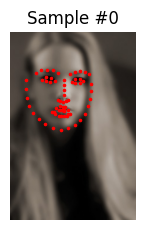

1 (500, 333, 3) (68, 2)


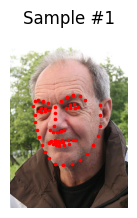

2 (250, 258, 3) (68, 2)


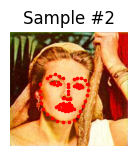

3 (434, 290, 3) (68, 2)


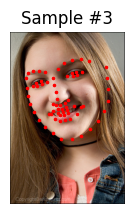

In [ ]:
face_dataset = FaceLandmarksDataset(csv_file='data/faces/face_landmarks.csv', root_dir='data/faces/')

fig = plt.figure()

for i, sample in enumerate(face_dataset):
  print(i, sample['image'].shape, sample['landmarks'].shape)

  ax = plt.subplot(1, 4, i + 1)
  plt.tight_layout()
  ax.set_title('Sample #{}'.format(i))
  ax.axis('off')
  show_landmarks(**sample)

  if i == 3:
    plt.show()
    break


In [ ]:
class Rescale(object):
  def __init__(self, output_size):
    assert isinstance(output_size, (int, tuple))
    self.output_size = output_size

  def __call__(self, sample):
    image, landmarks = sample['image'], sample['landmarks']

    h, w = image.shape[:2]
    if isinstance(self.output_size, int):
      if h > w:
        new_h, new_w = self.output_size * h / w, self.output_size
      else:
        new_h, new_w = self.output_size, self.output_size * w / h
    else:
      new_h, new_w = self.output_size

    new_h, new_w = int(new_h), int(new_w)

    img = transform.resize(image, (new_h, new_w))
    landmarks = landmarks * [new_w / w, new_h / h]

    return {'image': img, 'landmarks': landmarks}

class RandomCrop(object):
  def __init__(self, output_size):
    assert isinstance(output_size, (int, tuple))
    if isinstance(output_size, int):
      self.output_size = (output_size, output_size)
    else:
      assert len(output_size) == 2
      self.output_size = output_size

  def __call__(self, sample):
    image, landmarks = sample['image'], sample['landmarks']

    h, w = image.shape[:2]
    new_h, new_w = self.output_size

    top = np.random.randint(0, h - new_h + 1)
    left = np.random.randint(0, w - new_w + 1)

    image = image[top: top + new_h,
                  left: left + new_w]

    landmarks = landmarks - [left, top]

    return {'image': image, 'landmarks': landmarks}

class ToTensor(object):
  def __call__(self, sample):
    image, landmarks = sample['image'], sample['landmarks']

    image = image.transpose((2, 0, 1))
    return {'image': torch.from_numpy(image),
            'landmarks': torch.from_numpy(landmarks)}

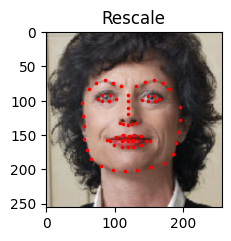

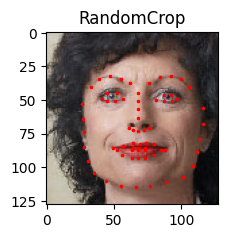

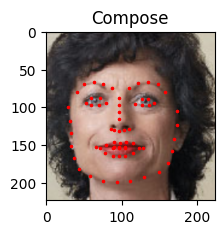

In [ ]:
scale = Rescale(256)
crop = RandomCrop(128)
composed = transforms.Compose([Rescale(256),
                               RandomCrop(224)])

fig = plt.figure()
sample = face_dataset[65]
for i, tsfrm in enumerate([scale, crop, composed]):
  transformed_sample = tsfrm(sample)

  ax = plt.subplot(1, 3, i + 1)
  plt.tight_layout()
  ax.set_title(type(tsfrm).__name__)
  show_landmarks(**transformed_sample)

plt.show()

In [ ]:
transformed_dataset = FaceLandmarksDataset(csv_file='data/faces/face_landmarks.csv',
                                           root_dir='data/faces/',
                                           transform=transforms.Compose([
                                               Rescale(256),
                                               RandomCrop(224),
                                               ToTensor()
                                           ]))

for i, sample in enumerate(transformed_dataset):
  print(i, sample['image'].size(), sample['landmarks'].size())

  if i == 3:
    break

0 torch.Size([3, 224, 224]) torch.Size([68, 2])
1 torch.Size([3, 224, 224]) torch.Size([68, 2])
2 torch.Size([3, 224, 224]) torch.Size([68, 2])
3 torch.Size([3, 224, 224]) torch.Size([68, 2])
